# Sampling distributions, standard errors and the bootstrap

Small examples first, simulation second, real data last.

**What's in here**
- population vs sample
- the sampling distribution of the mean, and the standard error σ/√n
- standard error vs standard deviation
- standard errors of a proportion, a difference of means, a regression slope
- confidence intervals and what "95%" means
- the bootstrap, step by step
- when the bootstrap fails
- autocorrelated data: block bootstrap and effective sample size
- interview checks: standard error of a Sharpe ratio; "is the mean error a bias?"

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

## 1. Population vs sample

A population of 100,000 customers' daily kWh (lognormal: most small, a few large).
We only ever see a sample.

In [2]:
population = rng.lognormal(mean=np.log(8), sigma=0.5, size=100_000)
print("population mean:", round(population.mean(), 3))
print("population sd  :", round(population.std(), 3))

population mean: 9.056
population sd  : 4.868


In [3]:
sample = rng.choice(population, size=5)
print("one sample of 5:", sample.round(2))
print("sample mean    :", round(sample.mean(), 3))

one sample of 5: [ 4.34  6.72 13.9   8.41  8.38]
sample mean    : 8.351


The sample mean is not the population mean. A different sample gives a different mean.
How different? That is the whole subject of this notebook.

## 2. The sampling distribution of the mean

Take 5 samples of n = 4 and print each with its mean.

In [4]:
n = 4
for i in range(5):
    sample = rng.choice(population, size=n)
    print(sample.round(2), " mean:", round(sample.mean(), 3))

[ 5.91 15.54  7.46  5.55]  mean: 8.615
[ 9.86 11.41  8.77 10.68]  mean: 10.182
[12.35  9.49  9.53  6.98]  mean: 9.587
[ 8.58 12.15  7.79  6.13]  mean: 8.665
[6.51 9.71 4.12 5.52]  mean: 6.466


The means wander around the true value 9.1. Now do it 10,000 times and look at the
spread of the means.

In [5]:
n = 4
means = np.empty(10_000)
for i in range(10_000):
    means[i] = rng.choice(population, size=n).mean()
print("mean of the 10,000 sample means:", round(means.mean(), 3), "  (population mean:", round(population.mean(), 3), ")")
print("sd of the 10,000 sample means  :", round(means.std(), 3))
print("population sd / sqrt(n)        :", round(population.std() / np.sqrt(n), 3))

mean of the 10,000 sample means: 9.081   (population mean: 9.056 )
sd of the 10,000 sample means  : 2.438
population sd / sqrt(n)        : 2.434


The sd of the sample means equals σ/√n. That quantity is the **standard error** of the mean.
Repeat for several n:

In [6]:
rows = []
for n in [4, 10, 50, 200, 1000]:
    sims = rng.choice(population, size=(10_000, n)).mean(axis=1)   # 10,000 samples at once
    rows.append({"n": n, "sd of sample means": sims.std(), "sigma/sqrt(n)": population.std() / np.sqrt(n)})
pd.DataFrame(rows).round(3)

,n,sd of sample means,sigma/sqrt(n)
0,4,2.455,2.434
1,10,1.535,1.539
2,50,0.681,0.688
3,200,0.345,0.344
4,1000,0.154,0.154


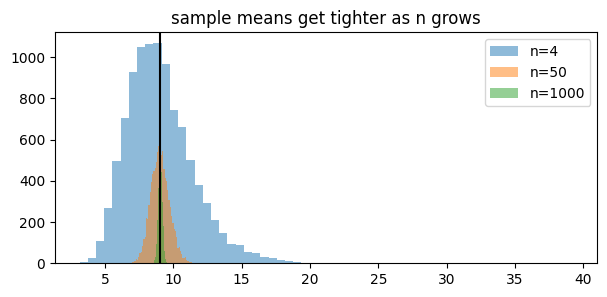

In [7]:
plt.figure(figsize=(7, 3))
for n in [4, 50, 1000]:
    sims = rng.choice(population, size=(10_000, n)).mean(axis=1)
    plt.hist(sims, bins=60, alpha=0.5, label=f"n={n}")
plt.axvline(population.mean(), color="k"); plt.legend(); plt.title("sample means get tighter as n grows"); plt.show()

Even though the population is skewed, the sample means look normal once n is moderate.
That is the central limit theorem.

**Pitfall:** it needs a finite variance. A Cauchy distribution has none, and its sample
mean never settles down:

In [8]:
for n in [10, 1000, 100_000]:
    cauchy_means = stats.cauchy.rvs(size=(200, n), random_state=rng).mean(axis=1)
    print(f"n={n:7d}  sd of sample means: {cauchy_means.std():8.2f}")

n=     10  sd of sample means:    18.30
n=   1000  sd of sample means:    66.83


n= 100000  sd of sample means:    11.31


## 3. Standard error vs standard deviation

Same sample, two numbers with different meanings.

In [9]:
sample = rng.choice(population, size=25)
sd = sample.std(ddof=1)
n = len(sample)
se = sd / np.sqrt(n)
print("sd  :", round(sd, 3), "  how spread out the customers are")
print("n   :", n)
print("se  :", round(se, 3), "  how uncertain our estimate of the mean is")

sd  : 3.863   how spread out the customers are
n   : 25
se  : 0.773   how uncertain our estimate of the mean is


As n grows the sd stays put (it describes the population) and the se shrinks:

In [10]:
rows = []
for n in [25, 100, 400, 1600]:
    sample = rng.choice(population, size=n)
    rows.append({"n": n, "sd": sample.std(ddof=1), "se": sample.std(ddof=1) / np.sqrt(n)})
pd.DataFrame(rows).round(3)

,n,sd,se
0,25,4.206,0.841
1,100,5.525,0.552
2,400,4.886,0.244
3,1600,4.758,0.119


### Other standard errors

A proportion: 30 solar customers out of 250. SE = √(p(1−p)/n).

In [11]:
k, n = 30, 250
p = k / n
se_p = np.sqrt(p * (1 - p) / n)
print("p    :", p)
print("se   :", round(se_p, 4))

p    : 0.12
se   : 0.0206


A difference of two means: SE = √(se₁² + se₂²).

In [12]:
a = np.array([10.0, 12.0, 11.0, 13.0, 9.0])
b = np.array([14.0, 15.0, 13.0, 16.0, 12.0])
se_a = a.std(ddof=1) / np.sqrt(len(a))
se_b = b.std(ddof=1) / np.sqrt(len(b))
print("difference of means:", b.mean() - a.mean())
print("se_a, se_b         :", round(se_a, 4), round(se_b, 4))
print("se of difference   :", round(np.sqrt(se_a**2 + se_b**2), 4))

difference of means: 3.0
se_a, se_b         : 0.7071 0.7071
se of difference   : 1.0


A regression slope: SE = σ_resid / √Σ(x − x̄)². Check the formula against `linregress`
and against simulation.

In [13]:
x = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y = np.array([1.2, 2.8, 5.1, 7.2, 8.9])
res = stats.linregress(x, y)
resid = y - (res.intercept + res.slope * x)
sigma = np.sqrt((resid**2).sum() / (len(x) - 2))
se_slope = sigma / np.sqrt(((x - x.mean())**2).sum())
print("slope           :", round(res.slope, 4))
print("se by formula   :", round(se_slope, 4))
print("linregress se   :", round(res.stderr, 4))

slope           : 1.98
se by formula   : 0.0653
linregress se   : 0.0653


In [14]:
slopes = np.empty(5000)
for i in range(5000):
    y_sim = 2 * x + 1 + rng.normal(0, sigma, size=len(x))
    slopes[i] = stats.linregress(x, y_sim).slope
print("sd of simulated slopes:", round(slopes.std(), 4))

sd of simulated slopes: 0.065


## 4. Confidence intervals

One sample of n = 30. A 95% interval for the mean, step by step.

In [15]:
sample = rng.choice(population, size=30)
mean = sample.mean()
se = sample.std(ddof=1) / np.sqrt(30)
z = stats.norm.ppf(0.975)
lower = mean - z * se
upper = mean + z * se
print("mean  :", round(mean, 3))
print("se    :", round(se, 3))
print("z     :", round(z, 3))
print("lower :", round(lower, 3))
print("upper :", round(upper, 3))
print("true  :", round(population.mean(), 3), " inside:", lower <= population.mean() <= upper)

mean  : 8.337
se    : 0.872
z     : 1.96
lower : 6.627
upper : 10.047
true  : 9.056  inside: True


What does "95%" mean? Build the interval 1,000 times from 1,000 different samples and count
how many contain the true mean.

In [16]:
for n in [30, 300, 3000]:
    hits = 0
    for i in range(1000):
        s = rng.choice(population, size=n)
        m = s.mean()
        e = s.std(ddof=1) / np.sqrt(n)
        if m - z * e <= population.mean() <= m + z * e:
            hits += 1
    print(f"n={n:4d}  coverage: {hits / 1000:.3f}")

n=  30  coverage: 0.902
n= 300  coverage: 0.933


n=3000  coverage: 0.953


Coverage climbs towards 95% as n grows (0.90 → 0.93 → 0.95). Any one interval either does or
does not; "95%" is a property of the procedure.

At n = 30 coverage is only about 90%: the population is skewed, so the sample mean is not
yet normal and the sample sd underestimates σ. The formula is an approximation that gets
better with n.

With small n use the t distribution, not 1.96. Coverage with z vs t at n = 5:

In [17]:
n = 5
for name, crit in [("z", stats.norm.ppf(0.975)), ("t", stats.t.ppf(0.975, df=n - 1))]:
    hits = 0
    for i in range(2000):
        s = rng.normal(size=n)
        m, e = s.mean(), s.std(ddof=1) / np.sqrt(n)
        hits += (m - crit * e <= 0 <= m + crit * e)
    print(f"{name}: critical value {crit:.3f}, coverage {hits / 2000:.3f}")

z: critical value 1.960, coverage 0.875


t: critical value 2.776, coverage 0.955


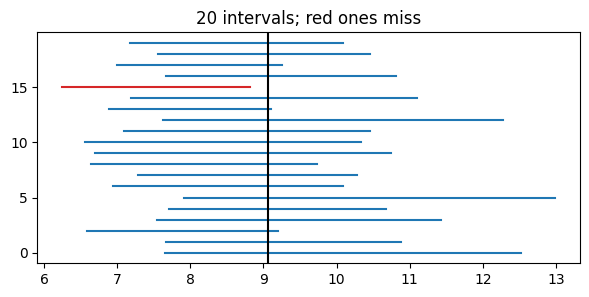

In [18]:
plt.figure(figsize=(7, 3))
for i in range(20):
    s = rng.choice(population, size=30)
    m, e = s.mean(), s.std(ddof=1) / np.sqrt(30)
    colour = "C0" if m - z * e <= population.mean() <= m + z * e else "C3"
    plt.plot([m - z * e, m + z * e], [i, i], color=colour)
plt.axvline(population.mean(), color="k"); plt.title("20 intervals; red ones miss"); plt.show()

## 5. The bootstrap

When there is no formula for the standard error, resample the data with replacement and
recompute the statistic. Start with 5 values and 3 resamples.

In [19]:
x = np.array([3.0, 7.0, 8.0, 12.0, 20.0])
print("data:", x, " mean:", x.mean())
for i in range(3):
    resample = rng.choice(x, size=len(x), replace=True)
    print("resample:", resample, " mean:", resample.mean())

data: [ 3.  7.  8. 12. 20.]  mean: 10.0
resample: [20. 20.  8.  7.  8.]  mean: 12.6
resample: [ 3.  3.  7. 20.  7.]  mean: 8.0
resample: [ 7. 20. 12.  8. 12.]  mean: 11.8


Some values appear twice, some not at all. Each resample mean is one draw from an
approximate sampling distribution. Now B = 2,000 resamples:

In [20]:
B = 2000
boot = np.empty(B)
for b in range(B):
    boot[b] = rng.choice(x, size=len(x), replace=True).mean()
print("bootstrap se        :", round(boot.std(), 3))
print("formula se          :", round(x.std(ddof=1) / np.sqrt(len(x)), 3))
print("percentile 95% CI   :", np.percentile(boot, [2.5, 97.5]).round(2))

bootstrap se        : 2.552
formula se          : 2.881
percentile 95% CI   : [ 5.6 15.2]


Same recipe for any statistic. The median has no simple SE formula:

In [21]:
boot_median = np.empty(B)
for b in range(B):
    boot_median[b] = np.median(rng.choice(x, size=len(x), replace=True))
print("median:", np.median(x), " bootstrap CI:", np.percentile(boot_median, [2.5, 97.5]))

median: 8.0  bootstrap CI: [ 3. 20.]


A correlation: resample **pairs** (rows), never x and y separately.

In [22]:
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
y = np.array([2.0, 4.0, 5.0, 4.0, 5.0, 7.0])
boot_r = np.empty(B)
for b in range(B):
    idx = rng.integers(0, len(x), size=len(x))      # which rows to take
    boot_r[b] = np.corrcoef(x[idx], y[idx])[0, 1]
print("r:", round(np.corrcoef(x, y)[0, 1], 3), " bootstrap CI:", np.percentile(boot_r, [2.5, 97.5]).round(3))

r: 0.878  bootstrap CI: [nan nan]


/home/dim/.local/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/dim/.local/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [23]:
stats.bootstrap((x, y), lambda a, b: np.corrcoef(a, b)[0, 1], paired=True, n_resamples=B, random_state=rng).confidence_interval

ConfidenceInterval(low=nan, high=nan)

**Pitfall:** the bootstrap has its own noise. With B = 50 the CI edges jump around;
with B = 2000 they settle.

In [24]:
for B_small in [50, 200, 2000]:
    edges = []
    for rep in range(3):
        bm = np.empty(B_small)
        for b in range(B_small):
            bm[b] = rng.choice(x, size=len(x), replace=True).mean()
        edges.append(np.percentile(bm, 2.5))
    print(f"B={B_small:5d}  lower edge over 3 runs: {np.round(edges, 3)}")

B=   50  lower edge over 3 runs: [2.038 2.538 2.5  ]
B=  200  lower edge over 3 runs: [2.162 2.167 2.167]


B= 2000  lower edge over 3 runs: [2.167 2.167 2.167]


**Pitfall:** the bootstrap fails for extremes. The 99.9th percentile of 200 values is
basically the maximum, and resampling cannot produce values beyond the observed maximum.

In [25]:
big = rng.normal(size=200)
boot_q = np.empty(B)
for b in range(B):
    boot_q[b] = np.percentile(rng.choice(big, size=200, replace=True), 99.9)
print("observed max         :", round(big.max(), 3))
print("bootstrap CI for p99.9:", np.percentile(boot_q, [2.5, 97.5]).round(3), " (cannot exceed the max)")

observed max         : 2.36
bootstrap CI for p99.9: [2.108 2.36 ]  (cannot exceed the max)


## 6. Autocorrelated data: the iid bootstrap is wrong

A 12-value series. The iid bootstrap scrambles the order; a block bootstrap resamples
blocks of consecutive values (here length 3) so local dependence survives.

In [26]:
series = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0])
block_len = 3
starts = rng.integers(0, len(series) - block_len + 1, size=len(series) // block_len)
blocks = [series[s:s + block_len] for s in starts]
print("block starts   :", starts)
print("blocks         :", blocks)
print("block resample :", np.concatenate(blocks))

block starts   : [1 1 6 3]
blocks         : [array([2., 3., 4.]), array([2., 3., 4.]), array([7., 8., 9.]), array([4., 5., 6.])]
block resample : [2. 3. 4. 2. 3. 4. 7. 8. 9. 4. 5. 6.]


On real hourly consumption: the iid bootstrap SE of the mean vs block bootstrap vs the
effective-sample-size formula.

In [27]:
df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"])
cons = df["consumption_mwh"].values
n = len(cons)
rho = pd.Series(cons).autocorr(1)
n_eff = n * (1 - rho) / (1 + rho)
print("n      :", n)
print("rho    :", round(rho, 4))
print("n_eff  :", round(n_eff))
print("iid se :", round(cons.std() / np.sqrt(n), 1))
print("n_eff se:", round(cons.std() / np.sqrt(n_eff), 1))

n      : 17520
rho    : 0.935
n_eff  : 588
iid se : 31.8
n_eff se: 173.4


In [28]:
def block_bootstrap_se(x, block_len, B=500):
    n_blocks = len(x) // block_len
    means = np.empty(B)
    for b in range(B):
        starts = rng.integers(0, len(x) - block_len + 1, size=n_blocks)
        pieces = [x[s:s + block_len] for s in starts]
        means[b] = np.concatenate(pieces).mean()
    return means.std()

for L in [24, 168, 720]:
    print(f"block length {L:4d}h  se: {block_bootstrap_se(cons, L):6.1f}")

block length   24h  se:   77.8
block length  168h  se:  189.6


block length  720h  se:  354.1


The iid SE (about 30) is far too small. With daily or weekly blocks the SE is several
times larger, and it keeps growing with block length because consumption has seasonal
structure longer than a week. There is no single right answer; the lesson is that the
iid number is wrong by a large factor.

## 7. Interview checks

**"Your backtest Sharpe is 1.2 over 3 years. What is its standard error?"**
For a Sharpe ratio estimated from N observations, SE(SR) ≈ √((1 + SR²/2) / N), all in the
same units as the observations. With daily data: convert 1.2 annual to daily, apply the
formula with N = days, convert back with √252. For small SR this is close to 1/√T_years.
Check by simulation.

In [29]:
SR = 1.2
years = 3
days = 252 * years
SR_daily = SR / np.sqrt(252)
se_daily = np.sqrt((1 + SR_daily**2 / 2) / days)
se_formula = se_daily * np.sqrt(252)
print("SR daily        :", round(SR_daily, 4))
print("se (daily units):", round(se_daily, 4))
print("se (annual)     :", round(se_formula, 3))
print("1/sqrt(years)   :", round(1 / np.sqrt(years), 3))

daily_mu = SR_daily * 0.01      # daily mean that gives annual Sharpe 1.2 with sd 1%
sharpes = np.empty(2000)
for i in range(2000):
    r = rng.normal(daily_mu, 0.01, size=days)
    sharpes[i] = r.mean() / r.std(ddof=1) * np.sqrt(252)
print("simulated se:", round(sharpes.std(), 3))
print("so 1.2 +/- 0.6: a Sharpe of 1.2 on 3 years is about 2 standard errors from zero")

SR daily        : 0.0756
se (daily units): 0.0364
se (annual)     : 0.578
1/sqrt(years)   : 0.577
simulated se: 0.57
so 1.2 +/- 0.6: a Sharpe of 1.2 on 3 years is about 2 standard errors from zero


**"The mean forecast error is +80 MWh. Is the model biased?"**
t = mean / se. With iid se the answer is yes; with an autocorrelation-corrected se it is
much less clear.

In [30]:
errors = rng.normal(0, 1500, size=3500)
for i in range(1, len(errors)):                   # make them autocorrelated (AR(1), 0.7)
    errors[i] = 0.7 * errors[i - 1] + np.sqrt(1 - 0.7**2) * errors[i]
errors = errors - errors.mean() + 80              # force the mean error to be exactly 80
n = len(errors)
rho = pd.Series(errors).autocorr(1)
se_iid = errors.std(ddof=1) / np.sqrt(n)
se_eff = errors.std(ddof=1) / np.sqrt(n * (1 - rho) / (1 + rho))
print("mean error :", round(errors.mean(), 1))
print("rho        :", round(rho, 3))
print("t (iid)    :", round(errors.mean() / se_iid, 2))
print("t (n_eff)  :", round(errors.mean() / se_eff, 2))

mean error : 80.0
rho        : 0.702
t (iid)    : 3.11
t (n_eff)  : 1.3


## Quick reference — standard errors

| Statistic | SE |
|---|---|
| mean | s / √n |
| proportion | √(p(1−p)/n) |
| difference of means | √(s₁²/n₁ + s₂²/n₂) |
| regression slope | σ_resid / √Σ(x−x̄)² |
| correlation r | ≈ √((1−r²)/(n−2)) |
| Sharpe | √((1 + SR²/2) / N) in the data's units; ≈ 1/√T_years for daily data |
| anything else | bootstrap (block bootstrap if autocorrelated) |
| autocorrelated mean | replace n by n(1−ρ)/(1+ρ) |